# sts-sim benchmarks

Quick-start notebook for running deck/matchup benchmarks against the Rust combat engine.

Select the **sts-sim** kernel (Kernel → Change Kernel) so this picks up the `.venv` build of `sts_sim`.

In [2]:
import statistics

import matplotlib.pyplot as plt

from sts_sim.bench import (
    EASY_POOL,
    PRESETS,
    compare,
    compare_decks,
    run_deck,
    Encounter,
)
from sts_sim.scenarios import CardName

## Helper: `plot_result`

Prints the same summary line as `print(result)` and plots a histogram of
`result.hp_lost_outcomes`, with the mean (dashed line) and ±1 std dev (shaded
band) annotated.

In [3]:
def plot_result(result, bins=range(0, 81, 5)):
    print(result)

    mean = result.mean_hp_lost
    lost = result.hp_lost_outcomes
    std = statistics.stdev(lost) if len(lost) > 1 else 0.0

    plt.hist(lost, bins=bins, edgecolor="black")
    plt.axvspan(
        mean - std, mean + std, color="orange", alpha=0.2, label=f"std = {std:.1f}"
    )
    plt.axvline(mean, color="red", linestyle="--", label=f"mean = {mean:.1f}")
    plt.xlabel("HP lost")
    plt.ylabel("fights")
    plt.title(
        f"{result.label}  (wins={result.wins}/{result.total}, avg_turns={result.mean_turns:.1f})"
    )
    plt.legend()
    plt.show()

## Compare named deck presets against a monster

`compare` runs each preset deck for `seeds` fights (MCTS-guided play) and prints win rate / average HP lost.

In [3]:
results = compare(PRESETS, monster=Encounter.JAW_WORM, seeds=20, iterations=200)

 1. starter                                 wins=20/20  avg_lost= 11.4 ±0.7  p25/p50/p75=11/11/13  avg_turns= 1.9


 2. cut-defend                              wins=20/20  avg_lost= 11.1 ±0.9  p25/p50/p75=11/11/13  avg_turns= 1.7


 3. cut-2-defends                           wins=20/20  avg_lost= 10.9 ±0.5  p25/p50/p75=11/11/11  avg_turns= 1.6


 4. cut-bash                                wins=20/20  avg_lost= 16.1 ±1.4  p25/p50/p75=11/16/20  avg_turns= 3.0


 5. add-strike                              wins=20/20  avg_lost= 11.8 ±0.8  p25/p50/p75=11/11/13  avg_turns= 1.9


 6. add-iron-wave                           wins=20/20  avg_lost=  8.8 ±1.0  p25/p50/p75=6/8/12  avg_turns= 1.9


 7. add-inflame                             wins=20/20  avg_lost= 10.9 ±0.8  p25/p50/p75=11/11/11  avg_turns= 1.9


 8. swap-defend-for-iron-wave               wins=20/20  avg_lost=  9.4 ±0.7  p25/p50/p75=6/11/12  avg_turns= 1.9


## Run a single custom deck

Pass any card list as `deck` (or `None` for the scenario's default starter deck).

my-deck                                 wins=100/100  avg_lost= 60.8 ±0.6  p25/p50/p75=57/61/66  avg_turns= 3.9


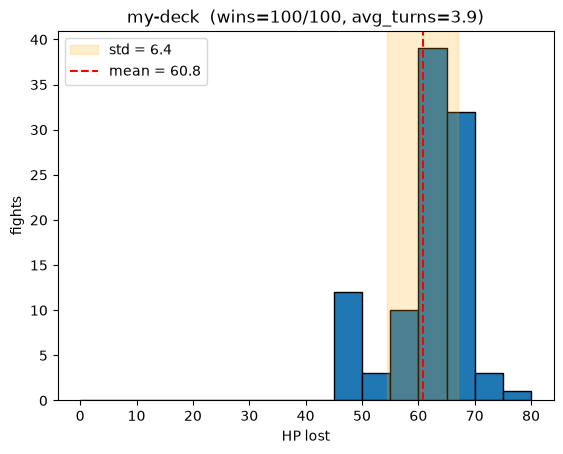

In [4]:
my_deck = [CardName.STRIKE] * 5 + [CardName.DEFEND] * 4 + [CardName.BASH]

result = run_deck(
    my_deck, monster=Encounter.BYRDONIS, seeds=100, iterations=200, label="my-deck"
)
plot_result(result)

my-deck                                 wins=30/30  avg_lost= 53.4 ±1.5  p25/p50/p75=48/54/61  avg_turns= 3.6


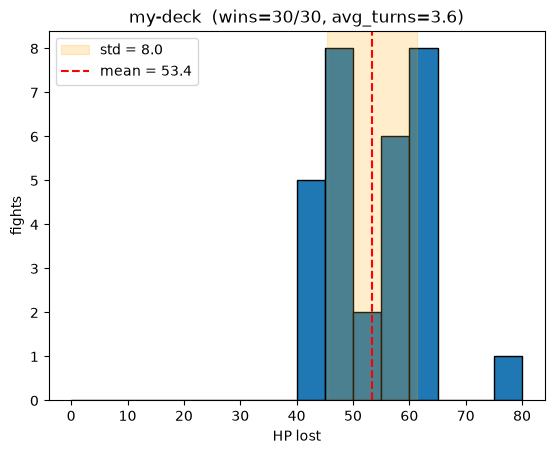

In [5]:
my_deck = (
    [CardName.STRIKE] * 5 + [CardName.DEFEND] * 5 + [CardName.BASH, CardName.INFLAME]
)

result = run_deck(
    my_deck, monster=Encounter.BYRDONIS, seeds=30, iterations=200, label="my-deck"
)
plot_result(result)

my-deck                                 wins=30/30  avg_lost= 12.7 ±0.4  p25/p50/p75=12/13/13  avg_turns= 1.9  ceiling=  3.1  regret=  9.6


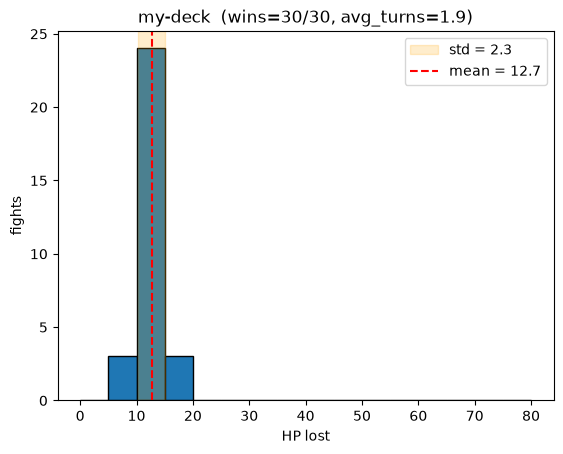

In [ ]:
my_deck = (
    [CardName.STRIKE] * 5 + [CardName.DEFEND] * 4 + [CardName.BASH]
)

result = run_deck(
    my_deck, monster=Encounter.NIBBIT, seeds=30, iterations=200, label="my-deck", ceiling=True,
)
plot_result(result)


my-deck                                 wins=30/30  avg_lost= 65.0 ±1.6  p25/p50/p75=56/67/72  avg_turns= 4.5


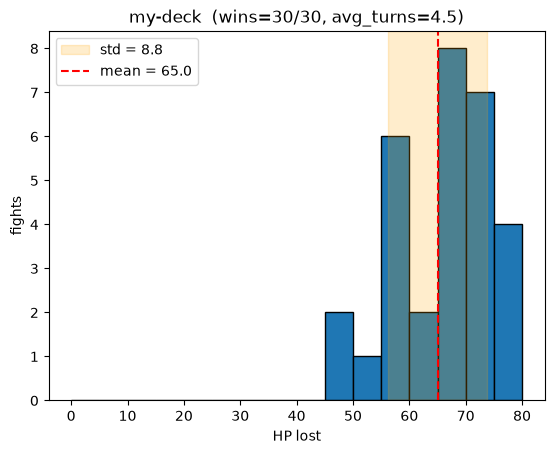

In [ ]:
my_deck = (
    [CardName.STRIKE] * 5 + [CardName.DEFEND] * 4 + [CardName.BASH, CardName.DAZED]
)

result = run_deck(
    my_deck, monster=Encounter.BYRDONIS, seeds=30, iterations=200, label="my-deck"
)
plot_result(result)

my-deck                                 wins=100/100  avg_lost= 57.8 ±0.8  p25/p50/p75=48/61/66  avg_turns= 3.7


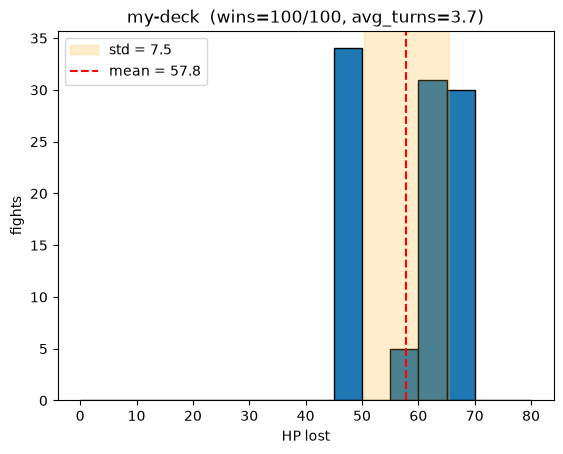

In [8]:
my_deck = [CardName.STRIKE] * 4 + [CardName.DEFEND] * 3 + [CardName.BASH]

result = run_deck(
    my_deck, monster=Encounter.BYRDONIS, seeds=100, iterations=200, label="my-deck"
)
plot_result(result)

## Compare two decks across multiple encounters

`compare_decks` runs each deck against each encounter with the same seeds
(paired comparison), and prints each deck's avg HP lost plus its
differential vs. the first ("baseline") deck — here the Act 1 "easy pool"
plus the Byrdonis elite.

In [7]:
starter_deck = [CardName.STRIKE] * 5 + [CardName.DEFEND] * 4 + [CardName.BASH]
add_break = [CardName.STRIKE] * 5 + [CardName.DEFEND] * 4 + [CardName.BREAK]
cut_deck = [CardName.STRIKE] * 4 + [CardName.DEFEND] * 3 + [CardName.BASH]
add_thunder = [CardName.STRIKE] * 5 + [CardName.DEFEND] * 4 + [CardName.BASH] + [CardName.THUNDERCLAP]
deck_results = compare_decks(
    {"starter": starter_deck, "add_break": add_break},
    EASY_POOL + [Encounter.BYRDONIS],
    seeds=30,
    iterations=200,
)

jaw-worm             starter= 11.7  add_break=  3.2 (Δ -8.5)
nibbit               starter= 12.7  add_break=  3.5 (Δ -9.1)
fuzzy-wurm-crawler   starter=  4.5  add_break=  0.3 (Δ -4.2)
twig-slime-s         starter=  0.0  add_break=  0.0 (Δ +0.0)
shrinker-beetle      starter=  7.8  add_break=  0.2 (Δ -7.5)
leaf-slime-s         starter=  0.0  add_break=  0.0 (Δ +0.0)
leaf-slime-m         starter=  0.9  add_break=  0.0 (Δ -0.9)
twig-slime-m         starter=  0.4  add_break=  0.0 (Δ -0.4)
slimes-weak          starter=  8.8  add_break=  1.6 (Δ -7.2)
slimes-weak-twig     starter= 16.1  add_break=  1.3 (Δ-14.8)
inklets              starter= 24.2  add_break= 13.8 (Δ-10.4)
byrdonis             starter= 61.0  add_break= 31.3 (Δ-29.7)


## Raw HP-lost data per fight

For custom analysis (plots, paired comparisons), inspect `result.hp_lost_outcomes` directly.

In [10]:
result.hp_lost_outcomes

[66,
 48,
 66,
 61,
 61,
 48,
 48,
 61,
 48,
 48,
 66,
 66,
 66,
 66,
 48,
 61,
 48,
 66,
 56,
 66,
 48,
 48,
 48,
 66,
 61,
 61,
 48,
 66,
 61,
 66,
 48,
 61,
 66,
 48,
 48,
 56,
 48,
 48,
 61,
 48,
 66,
 48,
 61,
 48,
 66,
 48,
 66,
 61,
 61,
 66,
 66,
 48,
 56,
 66,
 66,
 61,
 61,
 61,
 48,
 61,
 48,
 61,
 66,
 48,
 48,
 56,
 61,
 61,
 66,
 61,
 48,
 61,
 66,
 48,
 61,
 61,
 61,
 48,
 48,
 48,
 61,
 48,
 48,
 61,
 48,
 66,
 66,
 61,
 61,
 61,
 48,
 61,
 66,
 66,
 66,
 61,
 66,
 66,
 66,
 56]

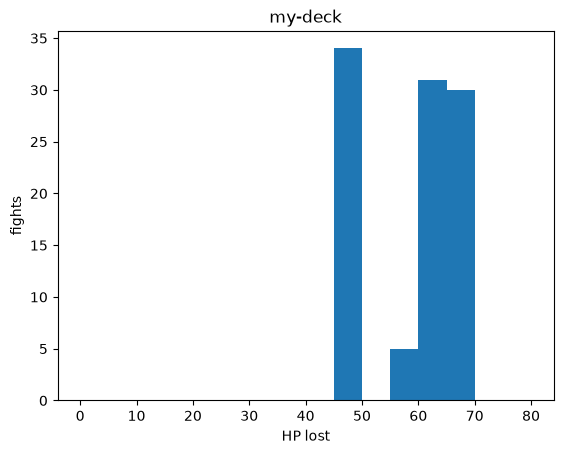

In [11]:
plt.hist(result.hp_lost_outcomes, bins=range(0, 81, 5))
plt.xlabel("HP lost")
plt.ylabel("fights")
plt.title(result.label)
plt.show()

## Lower-level API: `hp_lost_per_fight`

Build `CombatState`s directly for full control (e.g. paired common-random-number comparisons across decks).

In [12]:
from sts_sim import hp_lost_per_fight
from sts_sim.scenarios import ironclad_starter_deck_vs_jaw_worm

seeds = range(20)
starter_states = [ironclad_starter_deck_vs_jaw_worm(seed=s) for s in seeds]
cut_bash_states = [
    ironclad_starter_deck_vs_jaw_worm(
        seed=s, deck=[CardName.STRIKE] * 5 + [CardName.DEFEND] * 4
    )
    for s in seeds
]

starter_hp_lost = hp_lost_per_fight(starter_states, iterations=100)
cut_bash_hp_lost = hp_lost_per_fight(cut_bash_states, iterations=100)

print("starter   avg HP lost:", sum(starter_hp_lost) / len(starter_hp_lost))
print("cut-bash  avg HP lost:", sum(cut_bash_hp_lost) / len(cut_bash_hp_lost))

starter   avg HP lost: 10.65
cut-bash  avg HP lost: 15.55
